# Data Analysis - HCMC Weather and AQI
This notebook performs EDA on hourly weather and air-quality data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RAW_PATH = 'data/hcmc_weather_and_aqi.csv'
df = pd.read_csv(RAW_PATH)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.sort_values('datetime').reset_index(drop=True)

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (70560, 14)


,datetime,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2018-01-01 00:00:00,23.5,71,9.0,23,1009.7,0.0,6,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01 01:00:00,22.9,74,8.3,18,1009.5,0.0,10,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01 02:00:00,22.4,75,7.9,16,1009.0,0.0,16,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-01 03:00:00,22.0,75,8.6,15,1008.4,0.0,74,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01 04:00:00,21.9,75,8.9,14,1008.3,0.0,96,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
print('\nBasic info:')
df.info()

print('\nMissing values by column:')
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame('missing_count'))

pollutants = ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
print('\nLeading NaNs in pollutant columns:')
for col in pollutants:
    first_valid = df[col].first_valid_index()
    leading_nans = first_valid if first_valid is not None else len(df)
    print(f'{col}: {leading_nans}')


Basic info:
<class 'pandas.DataFrame'>
RangeIndex: 70560 entries, 0 to 70559
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              70560 non-null  datetime64[us]
 1   temperature_2m        70560 non-null  float64       
 2   relative_humidity_2m  70560 non-null  int64         
 3   wind_speed_10m        70560 non-null  float64       
 4   wind_direction_10m    70560 non-null  int64         
 5   surface_pressure      70560 non-null  float64       
 6   precipitation         70560 non-null  float64       
 7   cloud_cover           70560 non-null  int64         
 8   pm2_5                 30329 non-null  float64       
 9   pm10                  30329 non-null  float64       
 10  carbon_monoxide       30329 non-null  float64       
 11  nitrogen_dioxide      30329 non-null  float64       
 12  sulphur_dioxide       30329 non-null  float64       
 13  ozone         

,missing_count
ozone,40231
sulphur_dioxide,40231
carbon_monoxide,40231
nitrogen_dioxide,40231
pm2_5,40231
pm10,40231
surface_pressure,0
wind_direction_10m,0
wind_speed_10m,0
relative_humidity_2m,0



Leading NaNs in pollutant columns:
pm2_5: 40231
pm10: 40231
carbon_monoxide: 40231
nitrogen_dioxide: 40231
sulphur_dioxide: 40231
ozone: 40231


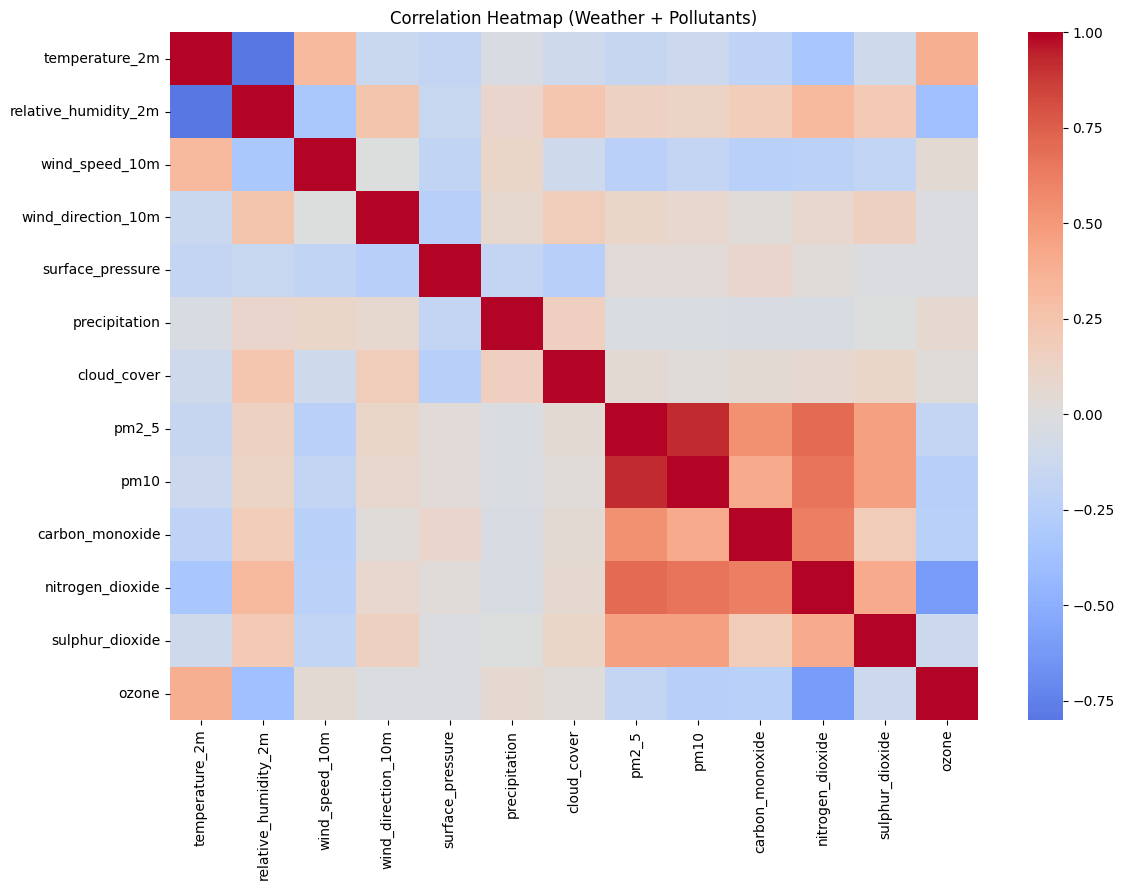

In [3]:
features = [
    'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
    'wind_direction_10m', 'surface_pressure', 'precipitation', 'cloud_cover',
    'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone'
]

corr_df = df[features].copy()
corr_df = corr_df.interpolate(method='linear').bfill().ffill()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (Weather + Pollutants)')
plt.tight_layout()
plt.show()

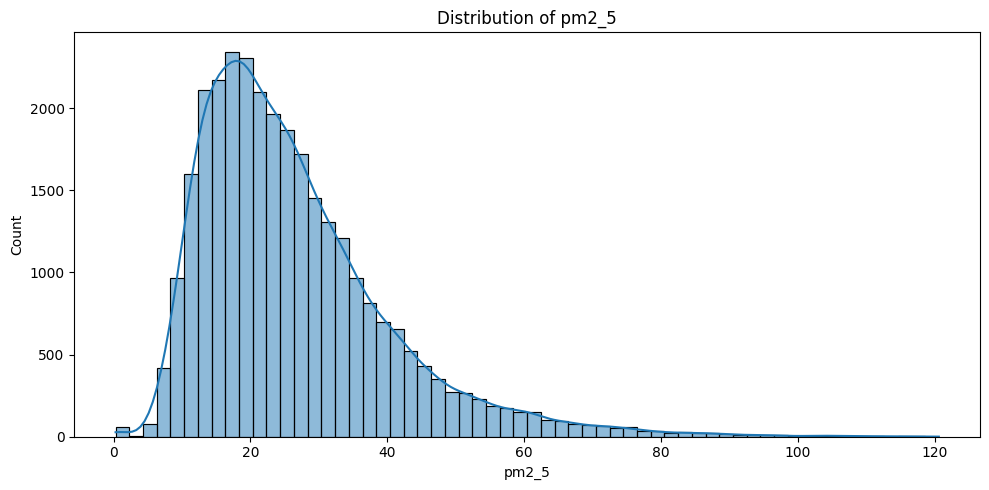

pm2_5 skewness: 1.5311277372341996


In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['pm2_5'].dropna(), bins=60, kde=True)
plt.title('Distribution of pm2_5')
plt.xlabel('pm2_5')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('pm2_5 skewness:', df['pm2_5'].dropna().skew())